# Notebook 5 - Evaluation and Comparison

This notebook evaluates the trained runs produced by the full three-run campaign in Notebook 4 and assembles the main comparative figures.

Interpretation rules:
- **Gaussian** is the exact DDPM baseline.
- **Uniform** and **Laplace** are matched-variance direct-corruption surrogates.
- The notebook still handles missing runs safely, but the intended workflow is now a complete three-way campaign from one Notebook 4 execution.



In [20]:
!pip install -q torch torchvision matplotlib numpy tqdm

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math, os, csv, json
from tqdm.notebook import tqdm

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/diffusion_noise_project'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
NOISE_TYPES = ['gaussian', 'uniform', 'laplace']
LABELS = {
    'gaussian': 'Gaussian (exact baseline)',
    'uniform': 'Uniform (matched-variance surrogate)',
    'laplace': 'Laplace (matched-variance surrogate)',
}
TABLE_LABELS = {
    'gaussian': 'Gaussian*',
    'uniform': 'Uniform[S]',
    'laplace': 'Laplace[S]',
}
COLORS = {'gaussian': '#4C72B0', 'uniform': '#DD8452', 'laplace': '#55A868'}
print(f'Torch version: {torch.__version__}')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}')
    print(f'Total GPU memory: {props.total_memory / 1024**3:.1f} GB')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Torch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4
Total GPU memory: 14.6 GB


## 1. Rebuild Model and Diffusion Classes

The notebook stays standalone by embedding the shared U-Net and diffusion definitions directly here.
The Laplace sampler below includes the same safety clamp used in Notebook 4.


In [22]:
# Standalone evaluation notebook: the shared model and diffusion definitions are embedded here.
# The Gaussian branch is exact; Uniform and Laplace remain matched-variance surrogate runs.

def make_beta_schedule(schedule, T, beta_start, beta_end):
    if schedule == 'linear':
        betas = torch.linspace(beta_start, beta_end, T)
    elif schedule == 'cosine':
        steps = T + 1
        x = torch.linspace(0, T, steps)
        alphas_cumprod = torch.cos(((x / T) + 0.008) / 1.008 * torch.pi / 2) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        betas = betas.clamp(0, 0.999)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]])
    return {
        'betas': betas, 'alphas': alphas,
        'alphas_cumprod': alphas_cumprod,
        'alphas_cumprod_prev': alphas_cumprod_prev,
        'sqrt_alphas_cumprod': alphas_cumprod.sqrt(),
        'sqrt_one_minus_alphas_cumprod': (1 - alphas_cumprod).sqrt(),
    }

class ForwardDiffusion:
    def __init__(self, schedule, device):
        self.device = device
        self.T = len(schedule['betas'])
        for k, v in schedule.items(): setattr(self, k, v.to(device))
    def sample_noise(self, shape): raise NotImplementedError
    def sample_timestep(self, batch_size):
        return torch.randint(0, self.T, (batch_size,), device=self.device).long()
    def q_sample(self, x_0, t):
        eps = self.sample_noise(x_0.shape)
        sqrt_ab = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_1ab = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ab * x_0 + sqrt_1ab * eps, eps

class GaussianDiffusion(ForwardDiffusion):
    def sample_noise(self, shape): return torch.randn(shape, device=self.device)

class UniformDiffusion(ForwardDiffusion):
    _a = 3 ** 0.5
    def sample_noise(self, shape):
        return torch.empty(shape, device=self.device).uniform_(-self._a, self._a)

class LaplaceDiffusion(ForwardDiffusion):
    _b = 2 ** -0.5
    _eps = 1e-6
    def sample_noise(self, shape):
        u = torch.empty(shape, device=self.device).uniform_(-0.5 + self._eps, 0.5 - self._eps)
        safe_term = (1 - 2 * u.abs()).clamp_min(1e-12)
        return -self._b * u.sign() * torch.log(safe_term)

DIFFUSION_CLASSES = {'gaussian': GaussianDiffusion, 'uniform': UniformDiffusion, 'laplace': LaplaceDiffusion}

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.proj = nn.Sequential(nn.Linear(dim, dim*4), nn.SiLU(), nn.Linear(dim*4, dim*4))
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / (half-1))
        args = t[:,None].float() * freqs[None]
        return self.proj(torch.cat([torch.sin(args), torch.cos(args)], dim=-1))

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, num_groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(num_groups, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(num_groups, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act = nn.SiLU()
        self.time_proj = nn.Linear(time_emb_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.act(self.norm1(x)); h = self.conv1(h)
        h = h + self.time_proj(self.act(t_emb))[:,:,None,None]
        h = self.act(self.norm2(h)); h = self.conv2(h)
        return h + self.skip(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, model_channels=64, channel_mults=(1,2,4)):
        super().__init__()
        time_emb_dim = model_channels * 4
        self.time_emb = SinusoidalTimeEmbedding(model_channels)
        chs = [model_channels * m for m in channel_mults]
        self.input_conv = nn.Conv2d(in_channels, chs[0], 3, padding=1)
        self.enc1 = ResBlock(chs[0], chs[0], time_emb_dim)
        self.down1 = nn.Conv2d(chs[0], chs[0], 4, stride=2, padding=1)
        self.enc2 = ResBlock(chs[0], chs[1], time_emb_dim)
        self.down2 = nn.Conv2d(chs[1], chs[1], 4, stride=2, padding=1)
        self.enc3 = ResBlock(chs[1], chs[2], time_emb_dim)
        self.mid1 = ResBlock(chs[2], chs[2], time_emb_dim)
        self.mid2 = ResBlock(chs[2], chs[2], time_emb_dim)
        self.up3 = nn.ConvTranspose2d(chs[2], chs[2], 4, stride=2, padding=1)
        self.dec3 = ResBlock(chs[2]+chs[1], chs[1], time_emb_dim)
        self.up2 = nn.ConvTranspose2d(chs[1], chs[1], 4, stride=2, padding=1)
        self.dec2 = ResBlock(chs[1]+chs[0], chs[0], time_emb_dim)
        self.dec1 = ResBlock(chs[0]+chs[0], chs[0], time_emb_dim)
        self.out_norm = nn.GroupNorm(8, chs[0]); self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(chs[0], in_channels, 1)
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        h0 = self.input_conv(x)
        h1 = self.enc1(h0, t_emb); h1d = self.down1(h1)
        h2 = self.enc2(h1d, t_emb); h2d = self.down2(h2)
        h3 = self.enc3(h2d, t_emb)
        h = self.mid2(self.mid1(h3, t_emb), t_emb)
        h = F.interpolate(self.up3(h), size=h2.shape[2:], mode='nearest')
        h = self.dec3(torch.cat([h, h2], dim=1), t_emb)
        h = F.interpolate(self.up2(h), size=h1.shape[2:], mode='nearest')
        h = self.dec2(torch.cat([h, h1], dim=1), t_emb)
        h = self.dec1(torch.cat([h, h0], dim=1), t_emb)
        return self.out_conv(self.out_act(self.out_norm(h)))

# --- END PASTE ---

CONFIG = {
    'T': 1000, 'beta_start': 1e-4, 'beta_end': 0.02, 'schedule': 'linear',
    'channels': 1, 'model_channels': 64, 'channel_mults': (1, 2, 4), 'batch_size': 128
}
schedule = make_beta_schedule(CONFIG['schedule'], CONFIG['T'], CONFIG['beta_start'], CONFIG['beta_end'])
print('Classes loaded.')

Classes loaded.


## 2. Load the Available Trained Models

Each checkpoint is paired with its saved run metadata. The notebook also verifies whether the available runs share the same training controls.



In [23]:
models = {}
diffusions = {}
run_metadata = {}
run_info_cache = {}

comparable_config_keys = [
    'batch_size', 'T', 'lr', 'num_epochs', 'optimizer',
    'weight_decay', 'model_channels', 'channel_mults', 'seed'
]

for noise_type in NOISE_TYPES:
    run_info_path = os.path.join(PROJECT_DIR, 'logs', f'{noise_type}_run_info.json')
    if os.path.exists(run_info_path):
        with open(run_info_path) as f:
            run_info_cache[noise_type] = json.load(f)

    ckpt_dir = os.path.join(PROJECT_DIR, 'checkpoints', noise_type)
    if not os.path.exists(ckpt_dir):
        print(f'WARNING: Missing checkpoint directory for {noise_type}: {ckpt_dir}')
        continue

    ckpts = sorted([f for f in os.listdir(ckpt_dir) if f.endswith('.pt')])
    if not ckpts:
        print(f'WARNING: No checkpoint found for {noise_type}. Skipping.')
        continue

    latest = os.path.join(ckpt_dir, ckpts[-1])
    ckpt = torch.load(latest, map_location=DEVICE)

    model = UNet(in_channels=1, model_channels=64, channel_mults=(1, 2, 4)).to(DEVICE)
    model.load_state_dict(ckpt['model'])
    model.eval()
    models[noise_type] = model
    diffusions[noise_type] = DIFFUSION_CLASSES[noise_type](schedule, DEVICE)

    info_from_log = run_info_cache.get(noise_type, {})
    run_metadata[noise_type] = {
        'checkpoint': ckpts[-1],
        'epoch': int(ckpt.get('epoch', -1)) + 1,
        'run_label': info_from_log.get('run_label', ckpt.get('run_label', LABELS[noise_type])),
        'training_objective': info_from_log.get('training_objective', ckpt.get('training_objective')),
        'sampler_note': info_from_log.get('sampler_note', ckpt.get('sampler_note')),
        'experimental_controls': info_from_log.get('experimental_controls', ckpt.get('experimental_controls')),
        'config': info_from_log.get('config', ckpt.get('config', {})),
        'duration_minutes': info_from_log.get('duration_minutes'),
        'peak_memory_gb': info_from_log.get('peak_memory_gb'),
    }

    print(f"{LABELS[noise_type]:42s} loaded from {ckpts[-1]} (epoch {run_metadata[noise_type]['epoch']})")

if not models:
    raise RuntimeError('No trained checkpoints found. Run Notebook 4 first before evaluating.')

missing_runs = [nt for nt in NOISE_TYPES if nt not in models]
print()
print(f'Loaded {len(models)} model(s).')
if missing_runs:
    print(f'Partial comparison only. Missing runs: {missing_runs}')

config_signatures = {}
for noise_type in models:
    cfg = run_metadata[noise_type].get('config', {})
    config_signatures[noise_type] = {key: cfg.get(key) for key in comparable_config_keys}

controls_verified = None
controls_reference = None
if len(config_signatures) >= 2:
    controls_reference = next(iter(config_signatures.values()))
    controls_verified = all(signature == controls_reference for signature in config_signatures.values())
    if controls_verified:
        print('Shared training controls verified across the available runs.')
    else:
        print('WARNING: training configuration mismatch detected across runs.')
        print(json.dumps(config_signatures, indent=2))
elif len(config_signatures) == 1:
    controls_reference = next(iter(config_signatures.values()))
    print('Only one completed run is available; the control check will become meaningful once the other runs finish.')



Gaussian (exact baseline)                  loaded from epoch_030.pt (epoch 30)
Uniform (matched-variance surrogate)       loaded from epoch_030.pt (epoch 30)
Laplace (matched-variance surrogate)       loaded from epoch_030.pt (epoch 30)

Loaded 3 model(s).
Shared training controls verified across the available runs.


## 3. Training Loss Curves

The plots below are honest about which runs are available. If one or two runs are missing, the figure stays valid and the final report can state that the comparison is still partial.


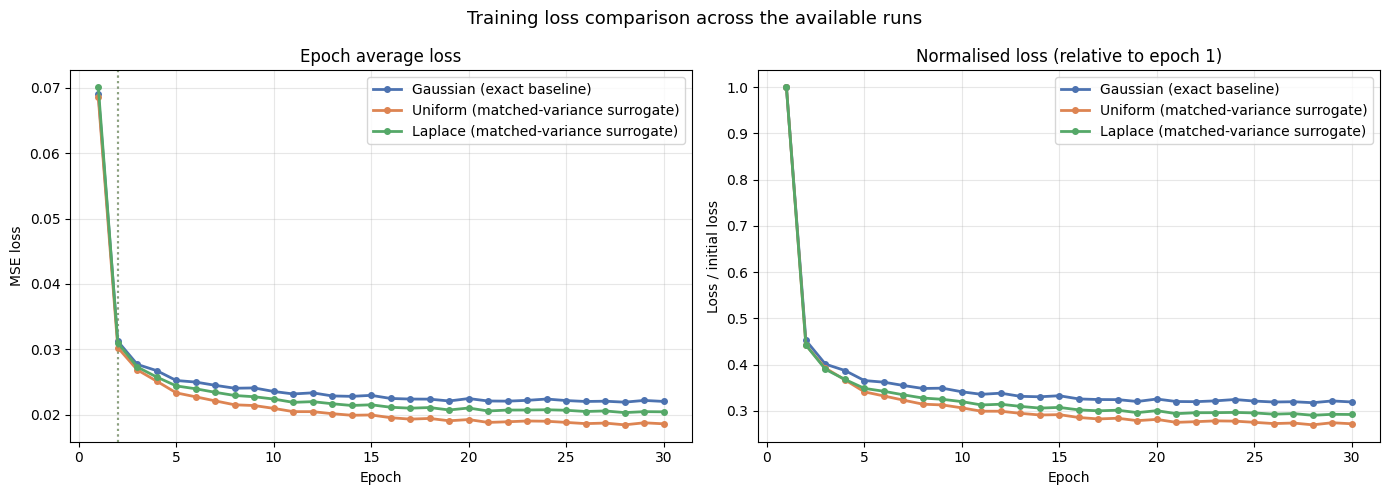

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for noise_type in NOISE_TYPES:
    log_path = os.path.join(PROJECT_DIR, 'logs', f'{noise_type}_loss.csv')
    if not os.path.exists(log_path):
        print(f'No log found for {noise_type}')
        continue

    epochs, epoch_losses = [], []
    with open(log_path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            epochs.append(int(row['epoch']))
            epoch_losses.append(float(row['epoch_avg_loss']))

    color = COLORS[noise_type]
    axes[0].plot(epochs, epoch_losses, marker='o', markersize=4,
                 label=LABELS[noise_type], color=color, linewidth=2)

    if epoch_losses:
        target = epoch_losses[0] * 0.5
        for i, loss_value in enumerate(epoch_losses):
            if loss_value <= target:
                axes[0].axvline(epochs[i], color=color, linestyle=':', alpha=0.5)
                break
        norm = [loss_value / epoch_losses[0] for loss_value in epoch_losses]
        axes[1].plot(epochs, norm, marker='o', markersize=4,
                     label=LABELS[noise_type], color=color, linewidth=2)

for ax, title, ylabel in zip(axes, ['Epoch average loss', 'Normalised loss (relative to epoch 1)'], ['MSE loss', 'Loss / initial loss']):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training loss comparison across the available runs', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'loss_comparison.png'), dpi=150)
plt.show()


## 4. Denoising MSE per Timestep t

This uses the same epsilon-prediction metric for each available run. For Gaussian the interpretation is exact. For Uniform and Laplace it remains a surrogate direct-corruption evaluation.


In [25]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
test_dataset = torchvision.datasets.MNIST(root='/content/data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=4,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    prefetch_factor=2,
)

eval_timesteps = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 999]
mse_by_t = {nt: {} for nt in NOISE_TYPES}

with torch.no_grad():
    for noise_type in tqdm(NOISE_TYPES, desc='Evaluating distributions'):
        if noise_type not in models:
            continue
        model = models[noise_type]
        diff = diffusions[noise_type]

        for t_val in tqdm(eval_timesteps, desc=f'  t steps [{noise_type}]', leave=False):
            batch_mses = []
            t_tensor = torch.tensor([t_val], device=DEVICE)

            for x_0, _ in test_loader:
                x_0 = x_0.to(DEVICE, non_blocking=PIN_MEMORY)
                t_batch = t_tensor.expand(x_0.shape[0])
                x_t, eps = diff.q_sample(x_0, t_batch)
                eps_pred = model(x_t, t_batch)
                mse = F.mse_loss(eps_pred, eps, reduction='none').mean(dim=(1, 2, 3))
                batch_mses.extend(mse.cpu().numpy().tolist())

            mse_by_t[noise_type][t_val] = np.mean(batch_mses)

print('Evaluation complete.')



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Evaluating distributions:   0%|          | 0/3 [00:00<?, ?it/s]

  t steps [gaussian]:   0%|          | 0/11 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  t steps [uniform]:   0%|          | 0/11 [00:00<?, ?it/s]

  t steps [laplace]:   0%|          | 0/11 [00:00<?, ?it/s]

Evaluation complete.


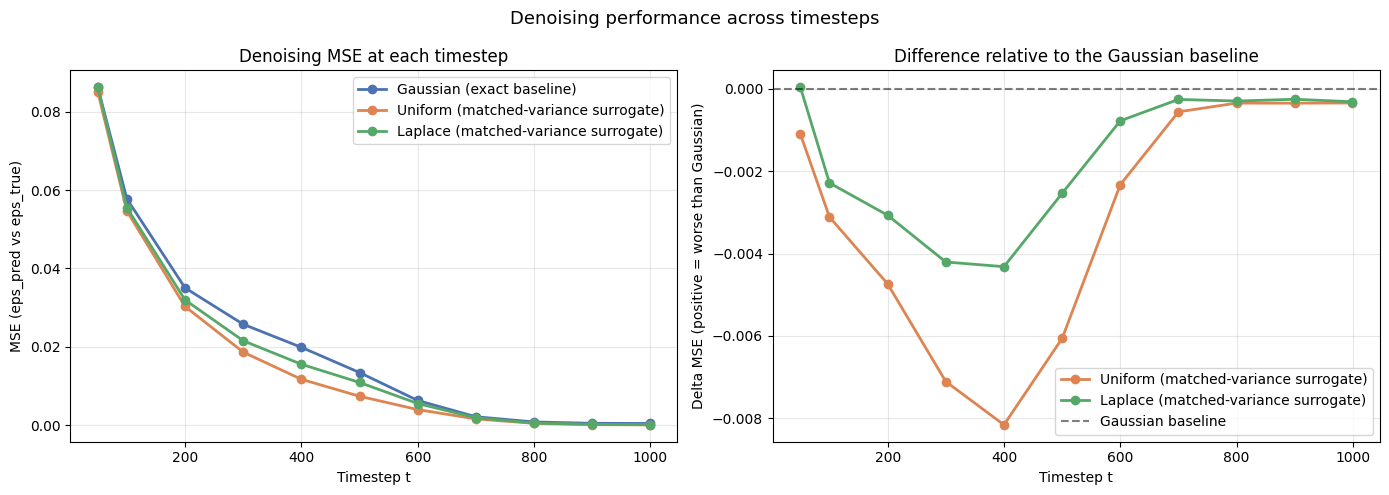

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for noise_type in NOISE_TYPES:
    if noise_type not in models:
        continue
    t_vals = sorted(mse_by_t[noise_type].keys())
    mses = [mse_by_t[noise_type][t] for t in t_vals]
    color = COLORS[noise_type]
    axes[0].plot(t_vals, mses, marker='o', label=LABELS[noise_type], color=color, linewidth=2)

axes[0].set_title('Denoising MSE at each timestep')
axes[0].set_xlabel('Timestep t')
axes[0].set_ylabel('MSE (eps_pred vs eps_true)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

comparison_candidates = [nt for nt in ['uniform', 'laplace'] if nt in models and mse_by_t.get('gaussian')]
if comparison_candidates:
    for noise_type in comparison_candidates:
        t_vals = sorted(mse_by_t[noise_type].keys())
        diff_from_gaussian = [mse_by_t[noise_type][t] - mse_by_t['gaussian'].get(t, 0.0) for t in t_vals]
        axes[1].plot(t_vals, diff_from_gaussian, marker='o', label=LABELS[noise_type], color=COLORS[noise_type], linewidth=2)
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5, label='Gaussian baseline')
    axes[1].set_title('Difference relative to the Gaussian baseline')
    axes[1].set_xlabel('Timestep t')
    axes[1].set_ylabel('Delta MSE (positive = worse than Gaussian)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'A true cross-distribution comparison appears here once\nGaussian and at least one non-Gaussian run are available.', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].axis('off')

plt.suptitle('Denoising performance across timesteps', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'mse_vs_timestep.png'), dpi=150)
plt.show()


## 5. Side-by-Side Generated Samples

Sampling still uses the standard Gaussian DDPM reverse update. That is exact for the Gaussian baseline and should be described as exploratory for Uniform and Laplace.


In [27]:
@torch.no_grad()
def ddpm_sample(model, diffusion, n_samples=16, device=DEVICE):
    model.eval()
    x = torch.randn((n_samples, 1, 28, 28), device=device)
    for t_val in reversed(range(diffusion.T)):
        t_batch = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)
        alpha_t = diffusion.alphas[t_val]
        alpha_bar_t = diffusion.alphas_cumprod[t_val]
        beta_t = diffusion.betas[t_val]
        coeff = (1 - alpha_t) / (1 - alpha_bar_t).sqrt()
        mean = (1 / alpha_t.sqrt()) * (x - coeff * eps_pred)
        x = mean + (beta_t.sqrt() * torch.randn_like(x) if t_val > 0 else 0)
    return x.clamp(-1, 1)

print('Generating 64 samples per available distribution...')
generated = {}
for noise_type in NOISE_TYPES:
    if noise_type not in models:
        continue
    print(f'  Sampling {LABELS[noise_type]}...')
    generated[noise_type] = ddpm_sample(models[noise_type], diffusions[noise_type], n_samples=64)
print('Done.')



Generating 64 samples per available distribution...
  Sampling Gaussian (exact baseline)...
  Sampling Uniform (matched-variance surrogate)...
  Sampling Laplace (matched-variance surrogate)...
Done.


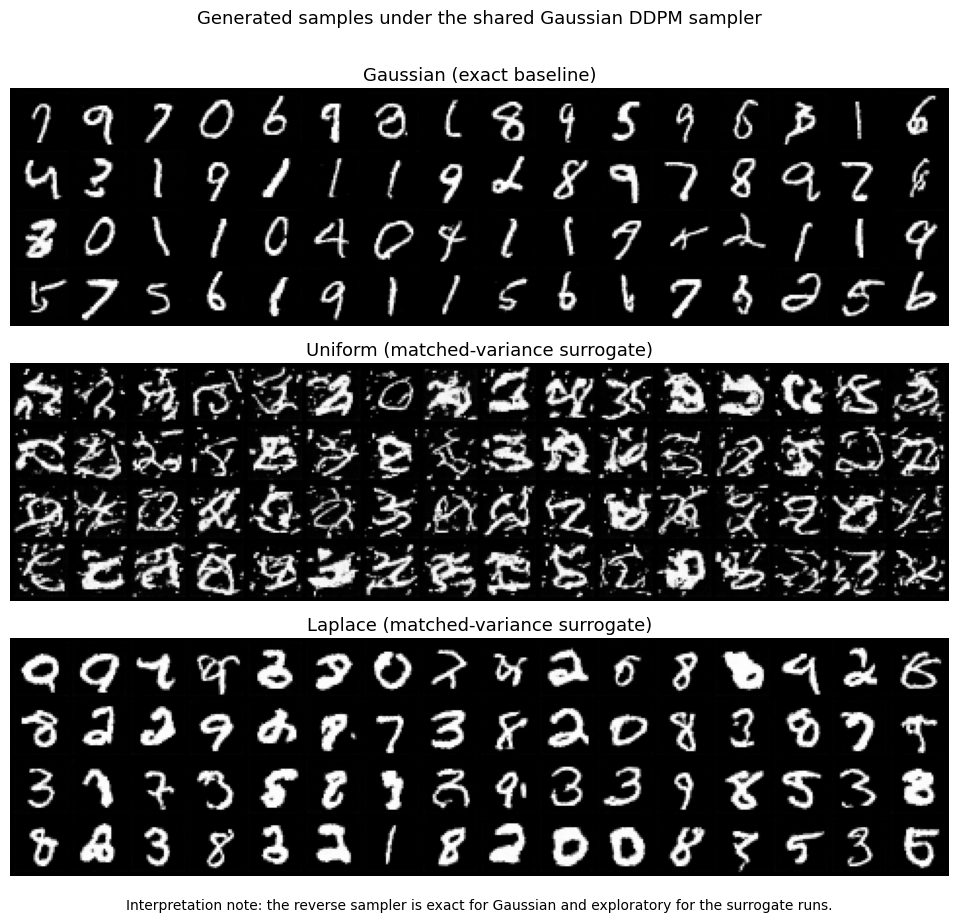

In [28]:
n_types = len(generated)
fig, axes = plt.subplots(n_types, 1, figsize=(16, max(1, n_types) * 3))
if n_types == 1:
    axes = [axes]

for ax, (noise_type, samples) in zip(axes, generated.items()):
    imgs = (samples * 0.5 + 0.5).clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs, nrow=16, padding=2)
    ax.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    ax.set_title(LABELS[noise_type], fontsize=13)
    ax.axis('off')

plt.suptitle('Generated samples under the shared Gaussian DDPM sampler', fontsize=13, y=1.01)
plt.figtext(0.5, 0.01, 'Interpretation note: the reverse sampler is exact for Gaussian and exploratory for the surrogate runs.', ha='center', fontsize=10)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'samples_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. Summary Statistics and Compact Report Files

The table and JSON summary below are designed for the final write-up. A compact metric figure is also saved for presentation use.



Metric                                  Gaussian*    Uniform[S]    Laplace[S]
-----------------------------------------------------------------------------
Final epoch avg loss                      0.02204       0.01862       0.02045
Avg denoising MSE (all t)                 0.02258       0.01947       0.02092
Denoising MSE at t=500                    0.01345       0.00739       0.01091
Denoising MSE at t=999                    0.00044       0.00010       0.00013
Sample diversity (pixel variance)         0.29293       0.47876       0.48622

* Gaussian = exact DDPM baseline.
[S] Uniform/Laplace = matched-variance surrogate runs.
Shared training controls verified across all available runs.
Evaluation summary saved to /content/drive/MyDrive/diffusion_noise_project/logs/evaluation_summary.json


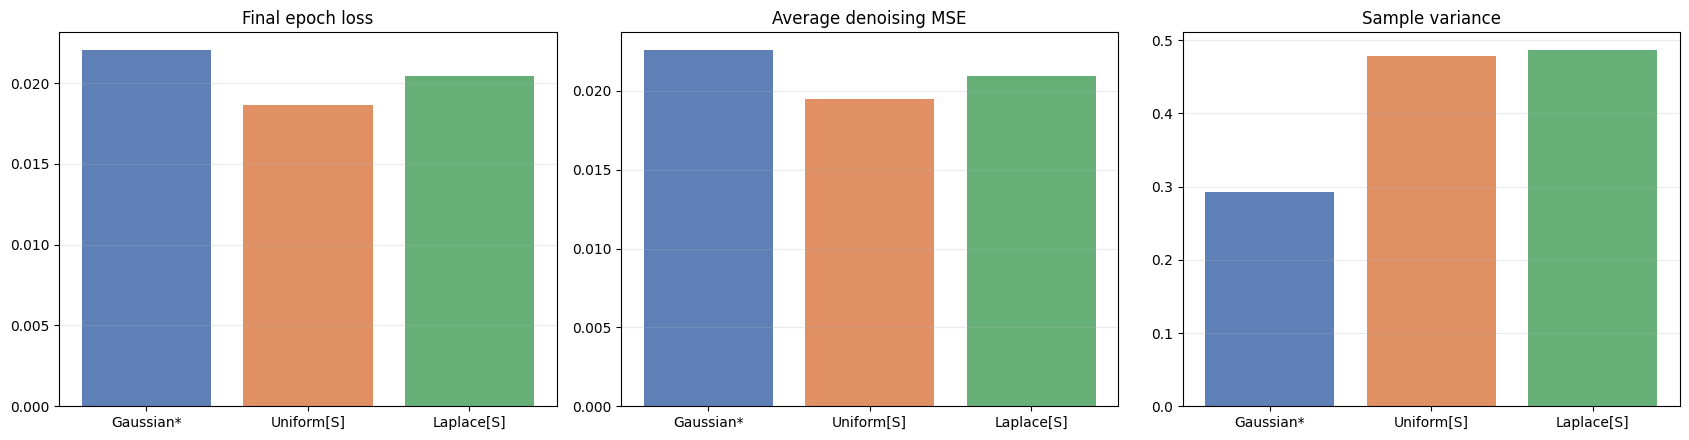

Metric overview figure saved to /content/drive/MyDrive/diffusion_noise_project/figures/metric_overview.png


In [29]:
summary_payload = {
    'available_runs': sorted(models.keys()),
    'missing_runs': [nt for nt in NOISE_TYPES if nt not in models],
    'full_comparison_ready': len(models) == len(NOISE_TYPES),
    'sampler_note': 'Notebook 5 uses the standard Gaussian DDPM reverse sampler for all runs.',
    'shared_controls_verified': controls_verified,
    'control_reference': controls_reference,
    'metrics': {},
}

print(f"{'Metric':<35}", end='')
for nt in NOISE_TYPES:
    print(f"{TABLE_LABELS[nt]:>14}", end='')
print()
print('-' * (35 + 14 * len(NOISE_TYPES)))

print(f"{'Final epoch avg loss':<35}", end='')
for nt in NOISE_TYPES:
    log_path = os.path.join(PROJECT_DIR, 'logs', f'{nt}_loss.csv')
    if os.path.exists(log_path):
        with open(log_path) as f:
            rows = list(csv.DictReader(f))
        val = float(rows[-1]['epoch_avg_loss']) if rows else None
        initial = float(rows[0]['epoch_avg_loss']) if rows else None
        half_epoch = None
        if rows and initial is not None:
            target = initial * 0.5
            for row in rows:
                if float(row['epoch_avg_loss']) <= target:
                    half_epoch = int(row['epoch'])
                    break
    else:
        val = None
        half_epoch = None
    summary_payload['metrics'].setdefault(nt, {})['final_epoch_avg_loss'] = val
    summary_payload['metrics'][nt]['half_loss_epoch'] = half_epoch
    summary_payload['metrics'][nt]['run_label'] = run_metadata.get(nt, {}).get('run_label', LABELS[nt])
    summary_payload['metrics'][nt]['checkpoint'] = run_metadata.get(nt, {}).get('checkpoint')
    summary_payload['metrics'][nt]['duration_minutes'] = run_metadata.get(nt, {}).get('duration_minutes')
    summary_payload['metrics'][nt]['peak_memory_gb'] = run_metadata.get(nt, {}).get('peak_memory_gb')
    print(f'{val:>14.5f}' if val is not None else f"{'MISSING':>14}", end='')
print()

print(f"{'Avg denoising MSE (all t)':<35}", end='')
for nt in NOISE_TYPES:
    if nt in mse_by_t and mse_by_t[nt]:
        avg = float(np.mean(list(mse_by_t[nt].values())))
        summary_payload['metrics'][nt]['avg_denoising_mse'] = avg
        print(f'{avg:>14.5f}', end='')
    else:
        summary_payload['metrics'][nt]['avg_denoising_mse'] = None
        print(f"{'MISSING':>14}", end='')
print()

print(f"{'Denoising MSE at t=500':<35}", end='')
for nt in NOISE_TYPES:
    val = mse_by_t.get(nt, {}).get(500)
    summary_payload['metrics'][nt]['mse_t500'] = float(val) if val is not None else None
    print(f'{val:>14.5f}' if val is not None else f"{'MISSING':>14}", end='')
print()

print(f"{'Denoising MSE at t=999':<35}", end='')
for nt in NOISE_TYPES:
    val = mse_by_t.get(nt, {}).get(999)
    summary_payload['metrics'][nt]['mse_t999'] = float(val) if val is not None else None
    print(f'{val:>14.5f}' if val is not None else f"{'MISSING':>14}", end='')
print()

print(f"{'Sample diversity (pixel variance)':<35}", end='')
for nt in NOISE_TYPES:
    if nt in generated:
        var = float(generated[nt].var().item())
        summary_payload['metrics'][nt]['sample_variance'] = var
        print(f'{var:>14.5f}', end='')
    else:
        summary_payload['metrics'][nt]['sample_variance'] = None
        print(f"{'MISSING':>14}", end='')
print()

summary_path = os.path.join(PROJECT_DIR, 'logs', 'evaluation_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary_payload, f, indent=2)

print()
print('* Gaussian = exact DDPM baseline.')
print('[S] Uniform/Laplace = matched-variance surrogate runs.')
if controls_verified is True:
    print('Shared training controls verified across all available runs.')
elif controls_verified is False:
    print('WARNING: shared training controls are not consistent across the available runs.')
print(f'Evaluation summary saved to {summary_path}')

metric_specs = [
    ('final_epoch_avg_loss', 'Final epoch loss'),
    ('avg_denoising_mse', 'Average denoising MSE'),
    ('sample_variance', 'Sample variance'),
]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, (metric_key, title) in zip(axes, metric_specs):
    present = [nt for nt in NOISE_TYPES if summary_payload['metrics'][nt].get(metric_key) is not None]
    values = [summary_payload['metrics'][nt][metric_key] for nt in present]
    colors = [COLORS[nt] for nt in present]
    labels = [TABLE_LABELS[nt] for nt in present]
    if present:
        ax.bar(labels, values, color=colors, alpha=0.9)
        ax.set_title(title)
        ax.grid(True, axis='y', alpha=0.25)
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()

plt.tight_layout()
metric_fig_path = os.path.join(PROJECT_DIR, 'figures', 'metric_overview.png')
plt.savefig(metric_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Metric overview figure saved to {metric_fig_path}')



## 7. Denoising Trajectory Visualisation

This section is mainly for presentation. The labels now make it explicit whether the row corresponds to the exact baseline or to a surrogate run.


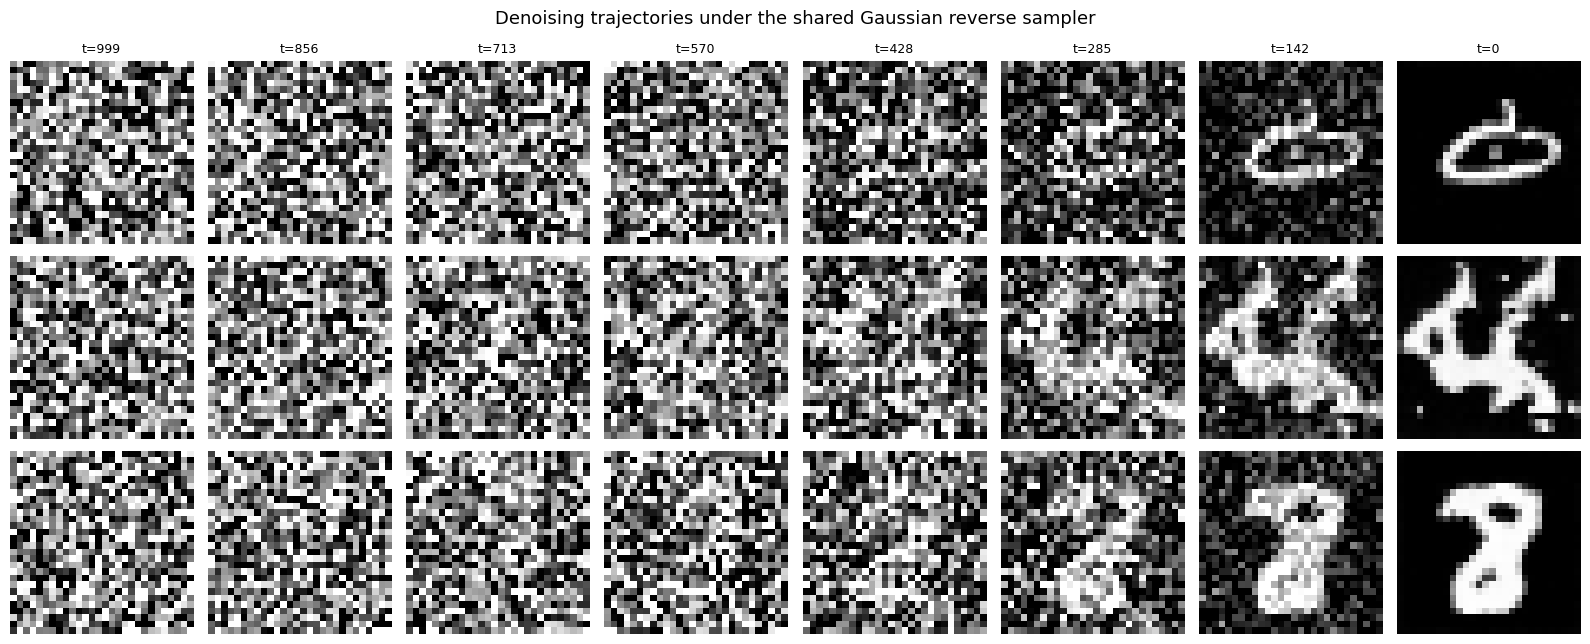

In [30]:
@torch.no_grad()
def sample_with_trajectory(model, diffusion, n_snapshots=8, device=DEVICE):
    x = torch.randn((1, 1, 28, 28), device=device)
    T = diffusion.T
    snapshot_steps = set(np.linspace(T - 1, 0, n_snapshots, dtype=int).tolist())
    snapshots = []

    for t_val in reversed(range(T)):
        t_batch = torch.tensor([t_val], device=device)
        eps_pred = model(x, t_batch)
        alpha_t = diffusion.alphas[t_val]
        alpha_bar_t = diffusion.alphas_cumprod[t_val]
        beta_t = diffusion.betas[t_val]
        coeff = (1 - alpha_t) / (1 - alpha_bar_t).sqrt()
        mean = (1 / alpha_t.sqrt()) * (x - coeff * eps_pred)
        x = mean + (beta_t.sqrt() * torch.randn_like(x) if t_val > 0 else 0)
        if t_val in snapshot_steps:
            snapshots.append((t_val, x.squeeze().cpu().numpy()))

    return snapshots

n_snapshots = 8
fig, axes = plt.subplots(len(models), n_snapshots, figsize=(16, len(models) * 2.2))
if len(models) == 1:
    axes = [axes]

for row, (noise_type, model) in enumerate(models.items()):
    snapshots = sample_with_trajectory(model, diffusions[noise_type], n_snapshots)
    for col, (t_val, img) in enumerate(snapshots):
        img_display = np.clip(img * 0.5 + 0.5, 0, 1)
        axes[row][col].imshow(img_display, cmap='gray', vmin=0, vmax=1)
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(f't={t_val}', fontsize=9)
        if col == 0:
            axes[row][col].set_ylabel(run_metadata.get(noise_type, {}).get('run_label', LABELS[noise_type]), fontsize=10)

plt.suptitle('Denoising trajectories under the shared Gaussian reverse sampler', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'trajectories.png'), dpi=150, bbox_inches='tight')
plt.show()


In [31]:
summary_path = os.path.join(PROJECT_DIR, 'logs', 'evaluation_summary.json')

print('Notebook 5 complete. All evaluation figures saved to:')
print(f'  {os.path.join(PROJECT_DIR, "figures")}')
print(f'  Summary JSON: {summary_path}')
print()
print('Figures produced:')
for f in sorted(os.listdir(os.path.join(PROJECT_DIR, 'figures'))):
    print(f'  {f}')
print()
if missing_runs:
    print(f'Current status: partial comparison only. Missing main runs: {missing_runs}')
else:
    print('Current status: full three-way comparison ready for Notebook 6.')
print('Proceed to Notebook 6 for the final write-up and export.')



Notebook 5 complete. All evaluation figures saved to:
  /content/drive/MyDrive/diffusion_noise_project/figures
  Summary JSON: /content/drive/MyDrive/diffusion_noise_project/logs/evaluation_summary.json

Figures produced:
  beta_schedule.png
  campaign_loss_overview.png
  campaign_samples.png
  forward_diffusion_comparison.png
  kurtosis_diagnostic.png
  loss_comparison.png
  metric_overview.png
  mnist_samples.png
  mse_vs_timestep.png
  noise_distributions.png
  noise_variance_vs_t.png
  samples_comparison.png
  trajectories.png

Current status: full three-way comparison ready for Notebook 6.
Proceed to Notebook 6 for the final write-up and export.
